# Predicting FLS2-flg22 Antagonism
The purpose of this notebook is to test several ML classification algorithms on the Colaianni dataset (Canonical/Immunogenic vs. Antagonist vs. Evading vs. Deviant). This code focuses on distinguishing Antagonists from Immunogenic peptides. 

Here, the Colaianni dataset is combined with the full Li dataset. Only sample from *Arabidosis thaliana* were used. Additionally, all peptides labeled as "Deviant" or "Evading" by Colaianni were removed. Peptides from the Li dataset labeled as "No Perception" that were not contained in the Colaianni dataset were removed, as there was not a way to definitively determine whether they were evading or antagonistic. Peptides labeled as "Perceived" by Li were kept and assumed to be immunogenic. 

---
### Importing Libraries and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

##### Inconsistencies in Data Labeling
Some peptide sequences are labeled as "Antagonists" by Colaianni but are labeled as "Perceived" (implying they elicit an immune response) by Li: flg22-1186, flg22-1410, flg22-5014, and flg22-5015. Due to the small number of antagonist samples (15), we did not want to eliminate these 4. To address this inconsistency, the models were tested on three modified versions of the dataset:
* **Test 1:** Peptides 1186, 1410, 5014, and 5015 were labeled as antagonistic.
    * 15 antagonistic, 25 immunogenic
* **Test 2:** Peptides 1186, 1410, 5014, and 5015 were labeled as immunogenic.
    * 11 antagonistic, 29 immunogenic
* **Test 3:** Peptides 1186, 1410, 5014, and 5015 were removed.
    * 11 antagonistic, 25 immunogenic

In [2]:
# Test 1 Data

df_test1 = pd.read_csv("antagonist_v_immunogenic_test1.csv", low_memory=False)

X_test1 = df_test1[
    [
        "avg_ptm",
        "avg_iptm",
        "avg_ligand_fls2_iptm",
        "avg_ligand_coreceptor_iptm",
        "avg_ligand_pae_min_fls2",
        "avg_ligand_pae_min_coreceptor"
    ]
].rename(columns={
    "avg_ptm": "ptm",
    "avg_iptm": "iptm",
    "avg_ligand_fls2_iptm": "FLS2-flg22 iptm",
    "avg_ligand_coreceptor_iptm": "BAK1-flg22 iptm",
    "avg_ligand_pae_min_fls2": "FLS2-flg22 pae",
    "avg_ligand_pae_min_coreceptor": "BAK1-flg22 pae"
})

y_test1 = df_test1[["Class"]]

# Combine X and y temporarily
data1 = X_test1.copy()
data1["target"] = y_test1

# Drop rows with ANY NaNs
data1 = data1.dropna()

# Split back
X_test1 = data1.drop(columns="target")
y_test1 = data1["target"]


X_test1.describe()

,ptm,iptm,FLS2-flg22 iptm,BAK1-flg22 iptm,FLS2-flg22 pae,BAK1-flg22 pae
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,0.881750,0.885167,0.826750,0.585167,3.216500,4.370583
std,0.013161,0.049968,0.105116,0.127122,1.849195,3.131590
min,0.826667,0.650000,0.510000,0.213333,1.700000,1.783333
25%,0.875833,0.872500,0.795833,0.539167,2.025833,2.274167
50%,0.886667,0.910000,0.875000,0.643333,2.340000,2.601667
75%,0.890000,0.910000,0.890833,0.673333,3.586667,5.823333
max,0.893333,0.920000,0.913333,0.713333,9.166667,13.996667


In [3]:
# Test 2 Data

df_test2 = pd.read_csv("antagonist_v_immunogenic_test2.csv", low_memory=False)

X_test2 = df_test2[
    [
        "avg_ptm",
        "avg_iptm",
        "avg_ligand_fls2_iptm",
        "avg_ligand_coreceptor_iptm",
        "avg_ligand_pae_min_fls2",
        "avg_ligand_pae_min_coreceptor"
    ]
].rename(columns={
    "avg_ptm": "ptm",
    "avg_iptm": "iptm",
    "avg_ligand_fls2_iptm": "FLS2-flg22 iptm",
    "avg_ligand_coreceptor_iptm": "BAK1-flg22 iptm",
    "avg_ligand_pae_min_fls2": "FLS2-flg22 pae",
    "avg_ligand_pae_min_coreceptor": "BAK1-flg22 pae"
})

y_test2 = df_test2[["Class"]]

# Combine X and y temporarily
data2 = X_test2.copy()
data2["target"] = y_test2

# Drop rows with ANY NaNs
data2 = data2.dropna()

# Split back
X_test2 = data2.drop(columns="target")
y_test2 = data2["target"]


X_test2.describe()

,ptm,iptm,FLS2-flg22 iptm,BAK1-flg22 iptm,FLS2-flg22 pae,BAK1-flg22 pae
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,0.881750,0.885167,0.826750,0.585167,3.216500,4.370583
std,0.013161,0.049968,0.105116,0.127122,1.849195,3.131590
min,0.826667,0.650000,0.510000,0.213333,1.700000,1.783333
25%,0.875833,0.872500,0.795833,0.539167,2.025833,2.274167
50%,0.886667,0.910000,0.875000,0.643333,2.340000,2.601667
75%,0.890000,0.910000,0.890833,0.673333,3.586667,5.823333
max,0.893333,0.920000,0.913333,0.713333,9.166667,13.996667


In [4]:
# Test 3 Data

df_test3 = pd.read_csv("antagonist_v_immunogenic_test3.csv", low_memory=False)

X_test3 = df_test3[
    [
        "avg_ptm",
        "avg_iptm",
        "avg_ligand_fls2_iptm",
        "avg_ligand_coreceptor_iptm",
        "avg_ligand_pae_min_fls2",
        "avg_ligand_pae_min_coreceptor"
    ]
].rename(columns={
    "avg_ptm": "ptm",
    "avg_iptm": "iptm",
    "avg_ligand_fls2_iptm": "FLS2-flg22 iptm",
    "avg_ligand_coreceptor_iptm": "BAK1-flg22 iptm",
    "avg_ligand_pae_min_fls2": "FLS2-flg22 pae",
    "avg_ligand_pae_min_coreceptor": "BAK1-flg22 pae"
})

y_test3 = df_test3[["Class"]]

# Combine X and y temporarily
data3 = X_test3.copy()
data3["target"] = y_test3

# Drop rows with ANY NaNs
data3 = data3.dropna()

# Split back
X_test3 = data3.drop(columns="target")
y_test3 = data3["target"]


X_test3.describe()

,ptm,iptm,FLS2-flg22 iptm,BAK1-flg22 iptm,FLS2-flg22 pae,BAK1-flg22 pae
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,0.881667,0.883241,0.823241,0.582037,3.227500,4.469074
std,0.013813,0.052333,0.110087,0.133122,1.943886,3.280275
min,0.826667,0.650000,0.510000,0.213333,1.700000,1.783333
25%,0.872500,0.867500,0.780000,0.535000,1.991667,2.266667
50%,0.888333,0.910000,0.876667,0.651667,2.223333,2.578333
75%,0.890000,0.910000,0.894167,0.674167,3.734167,5.955000
max,0.893333,0.920000,0.913333,0.713333,9.166667,13.996667


In [5]:
# Check each test set was imported correctly
print("Test 1 counts of Antagonists (0) and Immunogenic (1):")
print(y_test1.value_counts())
print("\nTest 2 counts of Antagonists (0) and Immunogenic (1):")
print(y_test2.value_counts())
print("\nTest 3 counts of Antagonists (0) and Immunogenic (1):")
print(y_test3.value_counts())

Test 1 counts of Antagonists (0) and Immunogenic (1):
1.0    25
0.0    15
Name: target, dtype: int64

Test 2 counts of Antagonists (0) and Immunogenic (1):
1.0    29
0.0    11
Name: target, dtype: int64

Test 3 counts of Antagonists (0) and Immunogenic (1):
1.0    25
0.0    11
Name: target, dtype: int64


---
### Feature Ranking

##### ANOVA F-test (Univariate)
"Does this feature have significantly different values between the two classes?"

Interpretation:
* Higher F-score: more separation between classes --> feature is more important
* Lower p-value: more statistically significant

Limitations: ignores feature interactions; assumes roughly linear separability

In [6]:
f_scores, p_values = f_classif(X_test1, y_test1)

anova_results = pd.DataFrame({
    "Feature": X_test1.columns,
    "F_score": f_scores,
    "p_value": p_values
}).sort_values(by="F_score", ascending=False)

anova_results.head(6)

,Feature,F_score,p_value
4,FLS2-flg22 pae,26.987039,0.000007
3,BAK1-flg22 iptm,25.342155,0.000012
5,BAK1-flg22 pae,23.885857,0.000019
2,FLS2-flg22 iptm,22.432474,0.000030
0,ptm,18.089886,0.000132
1,iptm,7.953686,0.007585


##### Logistic Regression
"How strongly does this feature influence the prediction in a linear model?"

Interpretation: 
* Larger magnitude: feature is more important
* Positive: increases probability of Class 1
* Negative: decreases probability of Class 1

Limitations: assumes linear relationships; sensitive to correlated features

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_test1)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_scaled, y_test1)

log_results = pd.DataFrame({
    "Feature": X_test1.columns,
    "Coefficient": log_model.coef_[0],
    "Abs_Coefficient": np.abs(log_model.coef_[0])
}).sort_values(by="Abs_Coefficient", ascending=False)

log_results.head(6)

,Feature,Coefficient,Abs_Coefficient
4,FLS2-flg22 pae,-0.859690,0.859690
0,ptm,0.746815,0.746815
1,iptm,-0.683873,0.683873
3,BAK1-flg22 iptm,0.510993,0.510993
2,FLS2-flg22 iptm,0.305182,0.305182
5,BAK1-flg22 pae,-0.281247,0.281247


##### Random Forest Feature Importance
"How much does this feature reduce impurity across decision trees?"

Interpretation:
* Higher importance: more useful for splitting
* Relative ranking matters more than absolute values

Limitations: biased toward features with more variability; not always stable for small datasets

In [8]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_test1, y_test1)

rf_results = pd.DataFrame({
    "Feature": X_test1.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_results.head(6)

,Feature,Importance
4,FLS2-flg22 pae,0.350107
5,BAK1-flg22 pae,0.157025
2,FLS2-flg22 iptm,0.147288
3,BAK1-flg22 iptm,0.132125
1,iptm,0.120860
0,ptm,0.092597


##### Permutation Importance (model-agnostic)
"How much does the model performance drop if this feature is randomly shuffled?"

Interpretation:
* Higher drop: feature more important
* Near zero: feature isn't useful

Limitations: biased toward features with more variability; not always stable for small datasets

In [9]:
perm = permutation_importance(
    rf, X_test1, y_test1,
    n_repeats=20,
    random_state=42
)

perm_results = pd.DataFrame({
    "Feature": X_test1.columns,
    "Importance": perm.importances_mean,
    "Std": perm.importances_std
}).sort_values(by="Importance", ascending=False)

perm_results.head(6)

,Feature,Importance,Std
4,FLS2-flg22 pae,0.22375,0.040678
1,iptm,0.05500,0.018708
2,FLS2-flg22 iptm,0.03375,0.016346
3,BAK1-flg22 iptm,0.02250,0.017500
5,BAK1-flg22 pae,0.02000,0.021794
0,ptm,0.01500,0.014577


In [10]:
# Define feature sets
feature_sets = {
    "All 6 features": [
        "ptm",
        "iptm",
        "FLS2-flg22 iptm",
        "BAK1-flg22 iptm",
        "FLS2-flg22 pae",
        "BAK1-flg22 pae"
    ],
    
    "Top 4 (interface)": [
        "FLS2-flg22 pae",
        "FLS2-flg22 iptm",
        "BAK1-flg22 iptm",
        "BAK1-flg22 pae"
    ],
    
    "Top 2 (FLS2)": [
        "FLS2-flg22 pae",
        "FLS2-flg22 iptm"
    ]
}

---
### Test 1 Classification

In [11]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [12]:
# Define models (in order of increasing complexity)
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

In [13]:
# Define scoring metrics
scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [14]:
# Run models across feature sets

results = []

for feature_set_name, feature_list in feature_sets.items():
    X_subset = X_test1[feature_list]
    
    for model_name, model in models.items():
        scores = cross_validate(
            model,
            X_subset,
            y_test1,
            cv=cv,
            scoring=scoring,
            return_train_score=False
        )
        
        result = {
            "Feature Set": feature_set_name,
            "Model": model_name,
            "N Features": len(feature_list),
            
            "ROC-AUC": scores["test_roc_auc"].mean(),
            "ROC-AUC std": scores["test_roc_auc"].std(),
            
            "Balanced Acc": scores["test_balanced_accuracy"].mean(),
            "Balanced Acc std": scores["test_balanced_accuracy"].std(),
            
            "Precision": scores["test_precision"].mean(),
            "Precision std": scores["test_precision"].std(),
            
            "Recall": scores["test_recall"].mean(),
            "Recall std": scores["test_recall"].std(),
            
            "F1": scores["test_f1"].mean(),
            "F1 std": scores["test_f1"].std()
        }
        
        results.append(result)
        
# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by ROC-AUC
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

# Show full results table
results_df.head(18)

,Feature Set,Model,N Features,ROC-AUC,ROC-AUC std,Balanced Acc,Balanced Acc std,Precision,Precision std,Recall,Recall std,F1,F1 std
0,All 6 features,Logistic Regression,6,0.946667,0.065320,0.740000,0.067987,0.812381,0.104918,0.88,0.160000,0.825152,0.051885
6,Top 4 (interface),Logistic Regression,4,0.946667,0.065320,0.720000,0.095685,0.802857,0.115061,0.84,0.149666,0.803939,0.064379
15,Top 2 (FLS2),SVM,2,0.946667,0.077746,0.893333,0.101980,0.926667,0.090431,0.92,0.097980,0.919596,0.075214
12,Top 2 (FLS2),Logistic Regression,2,0.946667,0.065320,0.760000,0.148174,0.802857,0.115061,0.92,0.097980,0.853939,0.093546
5,All 6 features,Gradient Boosting,6,0.926667,0.104137,0.820000,0.054160,0.893333,0.087939,0.84,0.149666,0.851414,0.064786
11,Top 4 (interface),Gradient Boosting,4,0.920000,0.116619,0.800000,0.036515,0.893333,0.087939,0.80,0.178885,0.823636,0.072122
17,Top 2 (FLS2),Gradient Boosting,2,0.920000,0.116619,0.860000,0.087939,0.893333,0.087939,0.92,0.097980,0.901414,0.063685
4,All 6 features,Random Forest,6,0.920000,0.106667,0.853333,0.090921,0.926667,0.090431,0.84,0.149666,0.869596,0.087274
3,All 6 features,SVM,6,0.906667,0.080000,0.853333,0.090921,0.926667,0.090431,0.84,0.149666,0.869596,0.087274
14,Top 2 (FLS2),KNN,2,0.906667,0.099778,0.893333,0.101980,0.926667,0.090431,0.92,0.097980,0.919596,0.075214


In [15]:
# Create summary table of ROC-AUC only
roc_table = results_df.pivot(index="Model", columns="Feature Set", values="ROC-AUC")
roc_table.head()

Feature Set,All 6 features,Top 2 (FLS2),Top 4 (interface)
Model,,,
Decision Tree,0.873333,0.860000,0.873333
Gradient Boosting,0.926667,0.920000,0.920000
KNN,0.860000,0.906667,0.840000
Logistic Regression,0.946667,0.946667,0.946667
Random Forest,0.920000,0.900000,0.900000


In [16]:
# Define plotting function

def plot_metric(results_df, metric, metric_std, title):
    import numpy as np
    import matplotlib.pyplot as plt
    
    model_order = results_df["Model"].unique()
    feature_set_order = results_df["Feature Set"].unique()
    
    x = np.arange(len(model_order))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for i, feature_set_name in enumerate(feature_set_order):
        subset = results_df[results_df["Feature Set"] == feature_set_name].copy()
        subset["Model"] = pd.Categorical(subset["Model"], categories=model_order, ordered=True)
        subset = subset.sort_values("Model")
        
        ax.bar(
            x + (i - 1) * width,
            subset[metric],
            width=width,
            yerr=subset[metric_std],
            capsize=4,
            label=feature_set_name
        )
    
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=30, ha="right")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.set_ylim(0.0, 1.1)
    ax.legend(title="Feature Set")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()

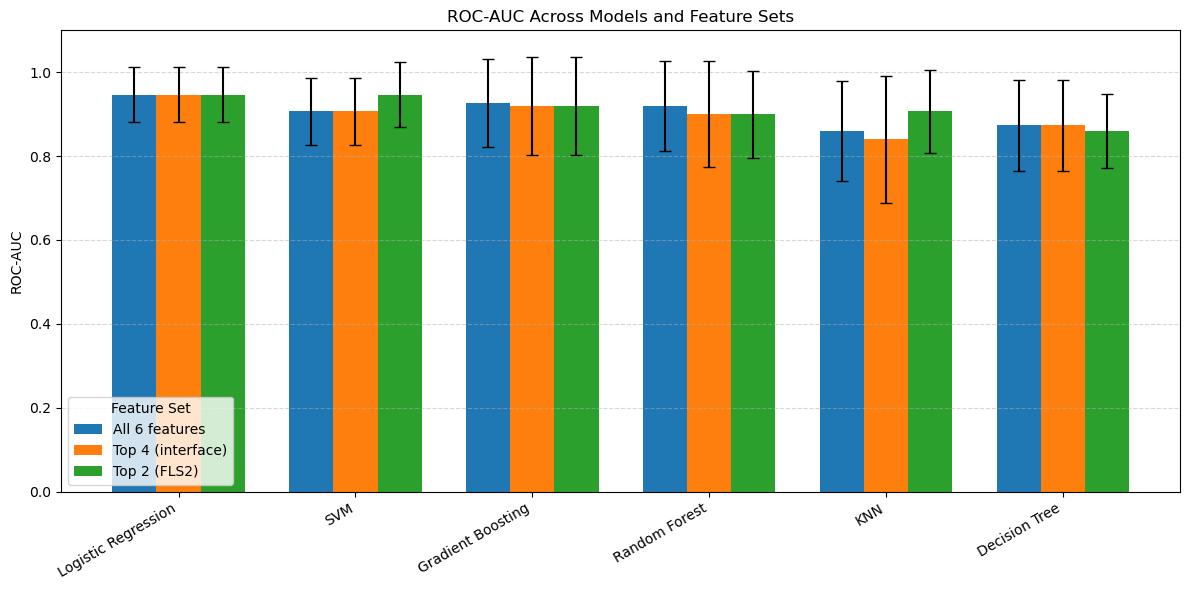

In [17]:
# Plot ROC-AUC
plot_metric(
    results_df,
    metric="ROC-AUC",
    metric_std="ROC-AUC std",
    title="ROC-AUC Across Models and Feature Sets"
)

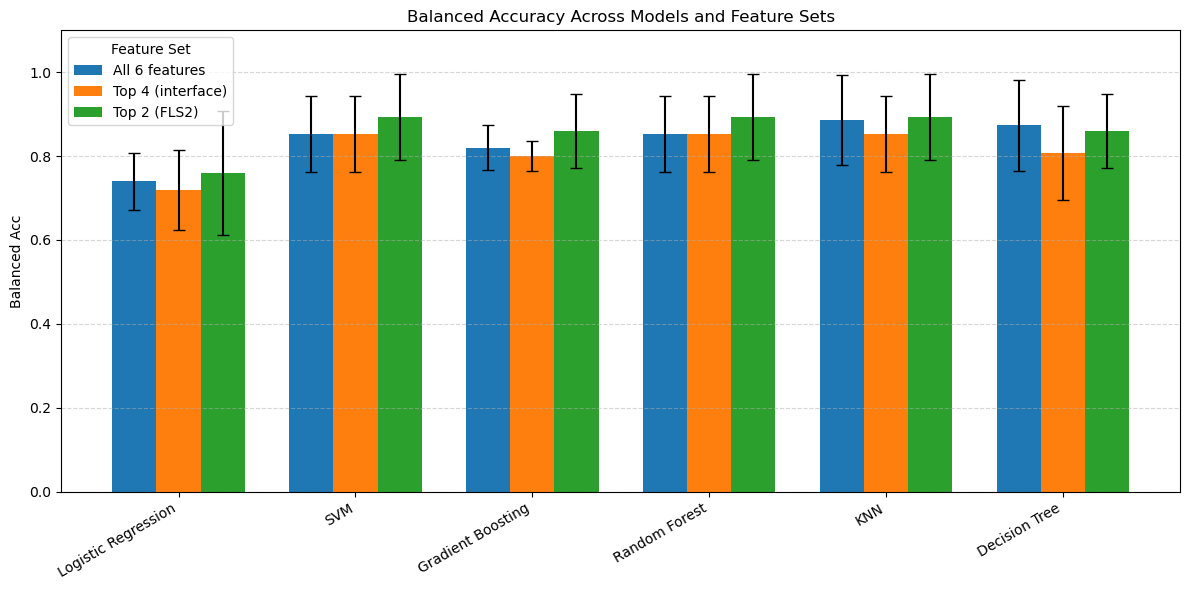

In [18]:
# Plot Balanced Accuracy
plot_metric(
    results_df,
    metric="Balanced Acc",
    metric_std="Balanced Acc std",
    title="Balanced Accuracy Across Models and Feature Sets"
)

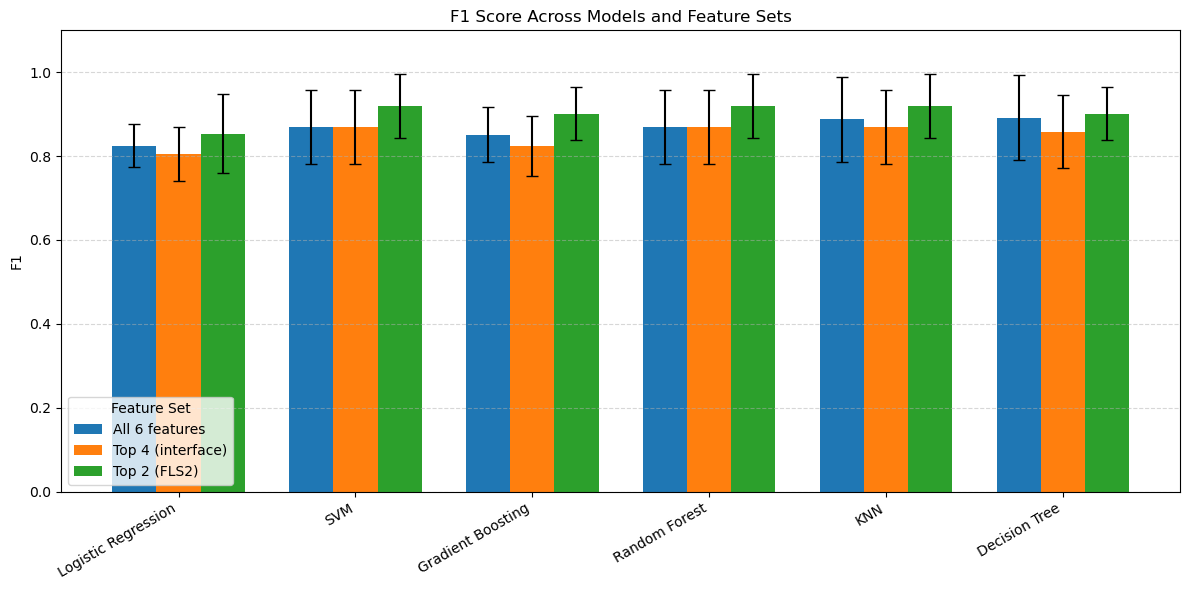

In [19]:
# Plot F1 Score

plot_metric(
    results_df,
    metric="F1",
    metric_std="F1 std",
    title="F1 Score Across Models and Feature Sets"
)

---
### Test 2 Classification

In [20]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [21]:
# Define models (in order of increasing complexity)
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

In [22]:
# Define scoring metrics
scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [23]:
# Run models across feature sets

results = []

for feature_set_name, feature_list in feature_sets.items():
    X_subset = X_test2[feature_list]
    
    for model_name, model in models.items():
        scores = cross_validate(
            model,
            X_subset,
            y_test2,
            cv=cv,
            scoring=scoring,
            return_train_score=False
        )
        
        result = {
            "Feature Set": feature_set_name,
            "Model": model_name,
            "N Features": len(feature_list),
            
            "ROC-AUC": scores["test_roc_auc"].mean(),
            "ROC-AUC std": scores["test_roc_auc"].std(),
            
            "Balanced Acc": scores["test_balanced_accuracy"].mean(),
            "Balanced Acc std": scores["test_balanced_accuracy"].std(),
            
            "Precision": scores["test_precision"].mean(),
            "Precision std": scores["test_precision"].std(),
            
            "Recall": scores["test_recall"].mean(),
            "Recall std": scores["test_recall"].std(),
            
            "F1": scores["test_f1"].mean(),
            "F1 std": scores["test_f1"].std()
        }
        
        results.append(result)
        
# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by ROC-AUC
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

# Show full results table
results_df.head(18)

,Feature Set,Model,N Features,ROC-AUC,ROC-AUC std,Balanced Acc,Balanced Acc std,Precision,Precision std,Recall,Recall std,F1,F1 std
0,All 6 features,Logistic Regression,6,0.933333,0.081650,0.783333,0.124722,0.880952,0.108588,0.900000,0.133333,0.877949,0.073471
6,Top 4 (interface),Logistic Regression,4,0.933333,0.081650,0.816667,0.152753,0.880952,0.108588,0.966667,0.066667,0.917949,0.074580
16,Top 2 (FLS2),Random Forest,2,0.933333,0.081650,0.900000,0.122474,0.966667,0.066667,0.900000,0.081650,0.930303,0.063275
12,Top 2 (FLS2),Logistic Regression,2,0.933333,0.081650,0.816667,0.152753,0.880952,0.108588,0.966667,0.066667,0.917949,0.074580
9,Top 4 (interface),SVM,4,0.933333,0.081650,0.766667,0.133333,0.876190,0.110040,0.866667,0.124722,0.860000,0.071181
8,Top 4 (interface),KNN,4,0.925000,0.066667,0.716667,0.145297,0.858333,0.138444,0.833333,0.105409,0.828998,0.046616
10,Top 4 (interface),Random Forest,4,0.925000,0.092796,0.750000,0.182574,0.858333,0.138444,0.900000,0.081650,0.868998,0.079078
14,Top 2 (FLS2),KNN,2,0.925000,0.092796,0.766667,0.161589,0.869524,0.113393,0.866667,0.124722,0.860606,0.090606
4,All 6 features,Random Forest,6,0.923333,0.067987,0.766667,0.133333,0.876190,0.110040,0.866667,0.124722,0.860000,0.071181
15,Top 2 (FLS2),SVM,2,0.916667,0.105409,0.800000,0.154560,0.893333,0.087939,0.866667,0.124722,0.875758,0.091111


In [24]:
# Create summary table of ROC-AUC only
roc_table = results_df.pivot(index="Model", columns="Feature Set", values="ROC-AUC")
roc_table.head()

Feature Set,All 6 features,Top 2 (FLS2),Top 4 (interface)
Model,,,
Decision Tree,0.816667,0.791667,0.763333
Gradient Boosting,0.805000,0.875000,0.771667
KNN,0.916667,0.925000,0.925000
Logistic Regression,0.933333,0.933333,0.933333
Random Forest,0.923333,0.933333,0.925000


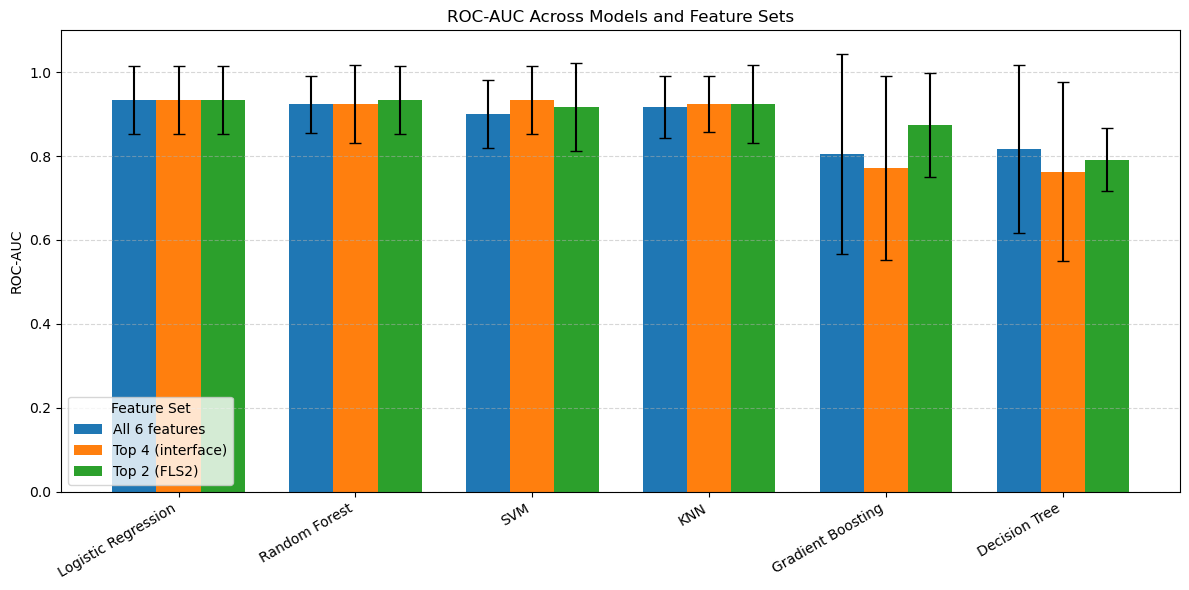

In [25]:
# Plot ROC-AUC
plot_metric(
    results_df,
    metric="ROC-AUC",
    metric_std="ROC-AUC std",
    title="ROC-AUC Across Models and Feature Sets"
)

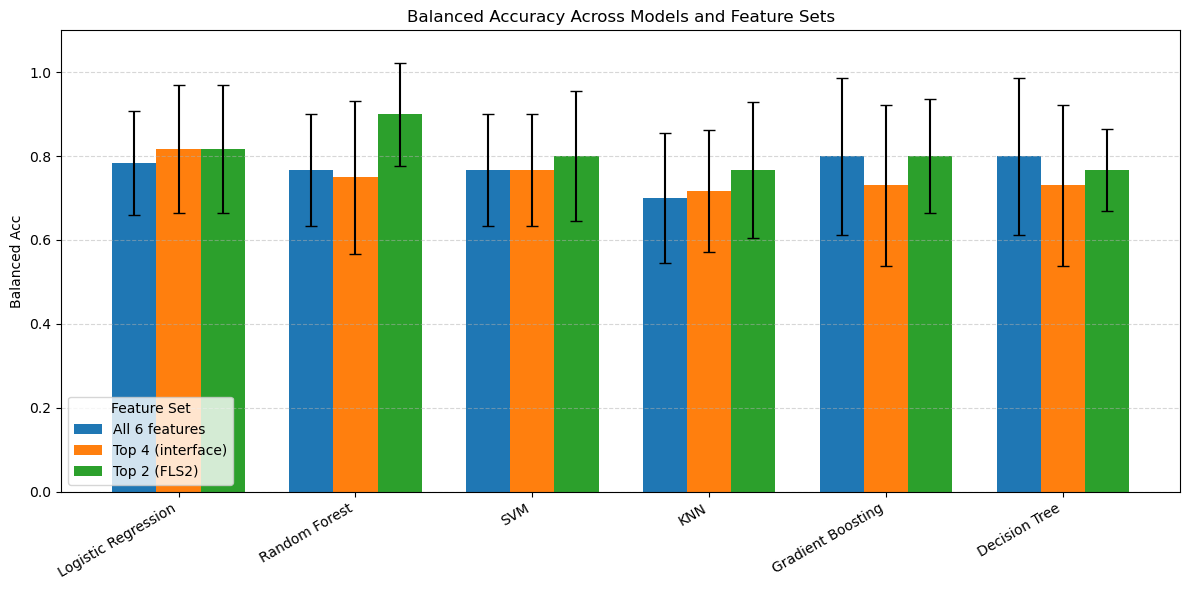

In [26]:
# Plot Balanced Accuracy
plot_metric(
    results_df,
    metric="Balanced Acc",
    metric_std="Balanced Acc std",
    title="Balanced Accuracy Across Models and Feature Sets"
)

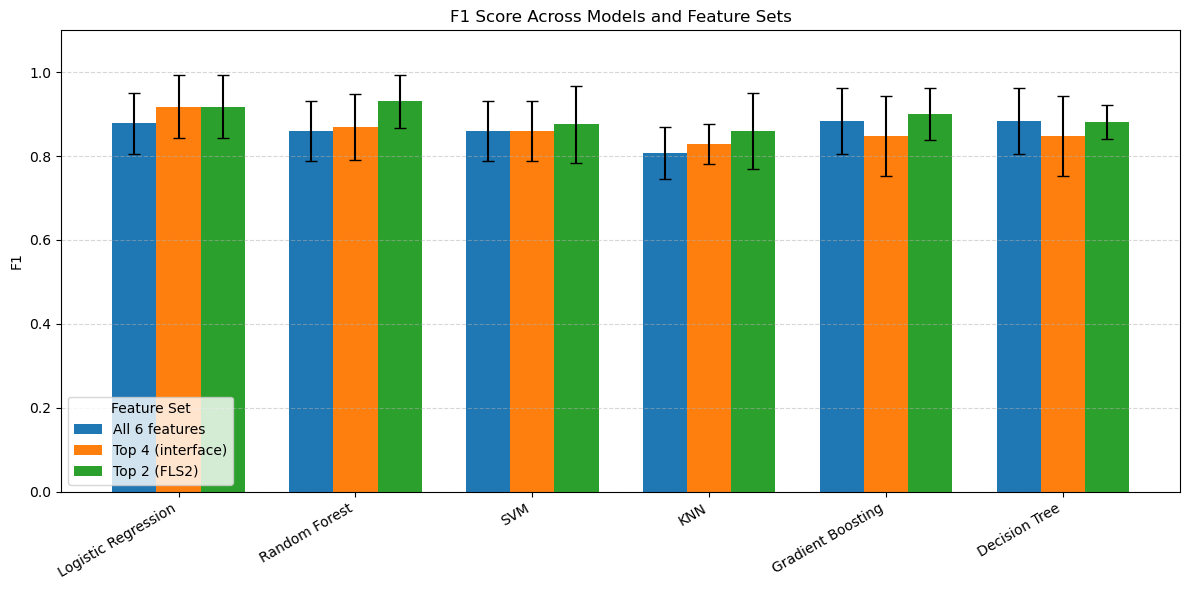

In [27]:
# Plot F1 Score

plot_metric(
    results_df,
    metric="F1",
    metric_std="F1 std",
    title="F1 Score Across Models and Feature Sets"
)

---
### Test 3 Classification

In [28]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [29]:
# Define models (in order of increasing complexity)
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

In [30]:
# Define scoring metrics
scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [31]:
# Run models across feature sets

results = []

for feature_set_name, feature_list in feature_sets.items():
    X_subset = X_test3[feature_list]
    
    for model_name, model in models.items():
        scores = cross_validate(
            model,
            X_subset,
            y_test3,
            cv=cv,
            scoring=scoring,
            return_train_score=False
        )
        
        result = {
            "Feature Set": feature_set_name,
            "Model": model_name,
            "N Features": len(feature_list),
            
            "ROC-AUC": scores["test_roc_auc"].mean(),
            "ROC-AUC std": scores["test_roc_auc"].std(),
            
            "Balanced Acc": scores["test_balanced_accuracy"].mean(),
            "Balanced Acc std": scores["test_balanced_accuracy"].std(),
            
            "Precision": scores["test_precision"].mean(),
            "Precision std": scores["test_precision"].std(),
            
            "Recall": scores["test_recall"].mean(),
            "Recall std": scores["test_recall"].std(),
            
            "F1": scores["test_f1"].mean(),
            "F1 std": scores["test_f1"].std()
        }
        
        results.append(result)
        
# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by ROC-AUC
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

# Show full results table
results_df.head(18)

,Feature Set,Model,N Features,ROC-AUC,ROC-AUC std,Balanced Acc,Balanced Acc std,Precision,Precision std,Recall,Recall std,F1,F1 std
0,All 6 features,Logistic Regression,6,0.953333,0.058119,0.823333,0.116237,0.909524,0.117031,0.88,0.160000,0.876263,0.082865
6,Top 4 (interface),Logistic Regression,4,0.953333,0.058119,0.863333,0.134330,0.909524,0.117031,0.96,0.080000,0.926263,0.065118
12,Top 2 (FLS2),Logistic Regression,2,0.953333,0.058119,0.813333,0.198438,0.885714,0.139971,0.96,0.080000,0.911111,0.075359
17,Top 2 (FLS2),Gradient Boosting,2,0.953333,0.058119,0.910000,0.091652,0.966667,0.066667,0.92,0.097980,0.937374,0.051663
16,Top 2 (FLS2),Random Forest,2,0.940000,0.080000,0.876667,0.116237,0.926667,0.090431,0.92,0.097980,0.919596,0.075214
14,Top 2 (FLS2),KNN,2,0.936667,0.077746,0.926667,0.104137,0.960000,0.080000,0.92,0.097980,0.937778,0.081225
3,All 6 features,SVM,6,0.933333,0.084327,0.803333,0.146211,0.900000,0.133333,0.84,0.149666,0.855051,0.102409
15,Top 2 (FLS2),SVM,2,0.933333,0.084327,0.926667,0.104137,0.960000,0.080000,0.92,0.097980,0.937778,0.081225
9,Top 4 (interface),SVM,4,0.933333,0.084327,0.803333,0.146211,0.900000,0.133333,0.84,0.149666,0.855051,0.102409
4,All 6 features,Random Forest,6,0.930000,0.087178,0.803333,0.146211,0.900000,0.133333,0.84,0.149666,0.855051,0.102409


In [32]:
# Create summary table of ROC-AUC only
roc_table = results_df.pivot(index="Model", columns="Feature Set", values="ROC-AUC")
roc_table.head()

Feature Set,All 6 features,Top 2 (FLS2),Top 4 (interface)
Model,,,
Decision Tree,0.910000,0.910000,0.910000
Gradient Boosting,0.850000,0.953333,0.870000
KNN,0.876667,0.936667,0.883333
Logistic Regression,0.953333,0.953333,0.953333
Random Forest,0.930000,0.940000,0.930000


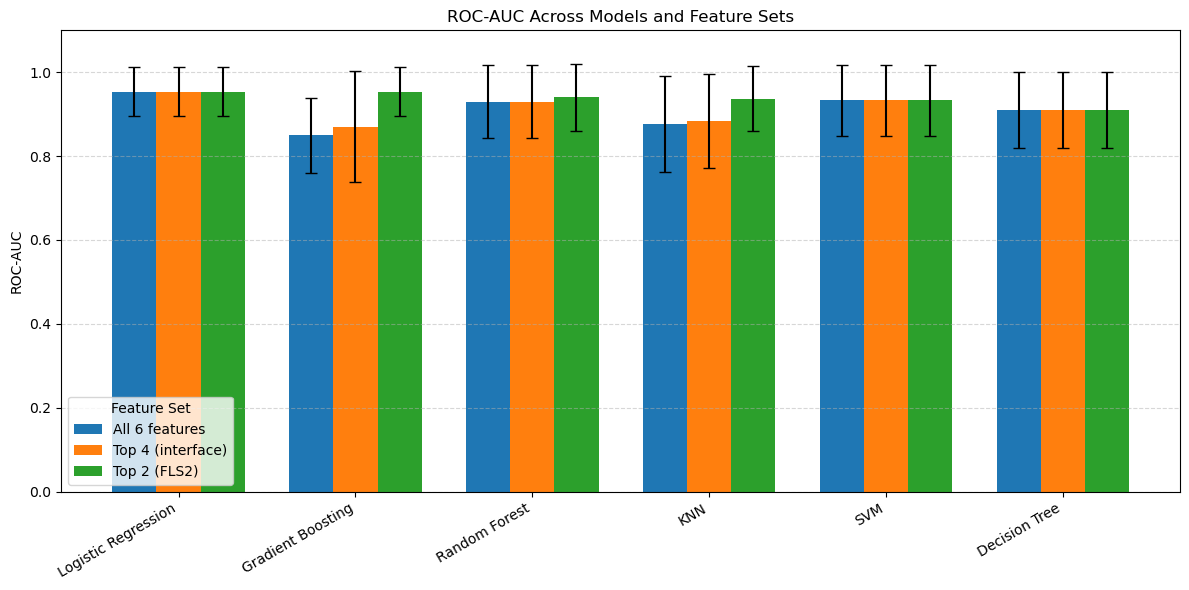

In [33]:
# Plot ROC-AUC
plot_metric(
    results_df,
    metric="ROC-AUC",
    metric_std="ROC-AUC std",
    title="ROC-AUC Across Models and Feature Sets"
)

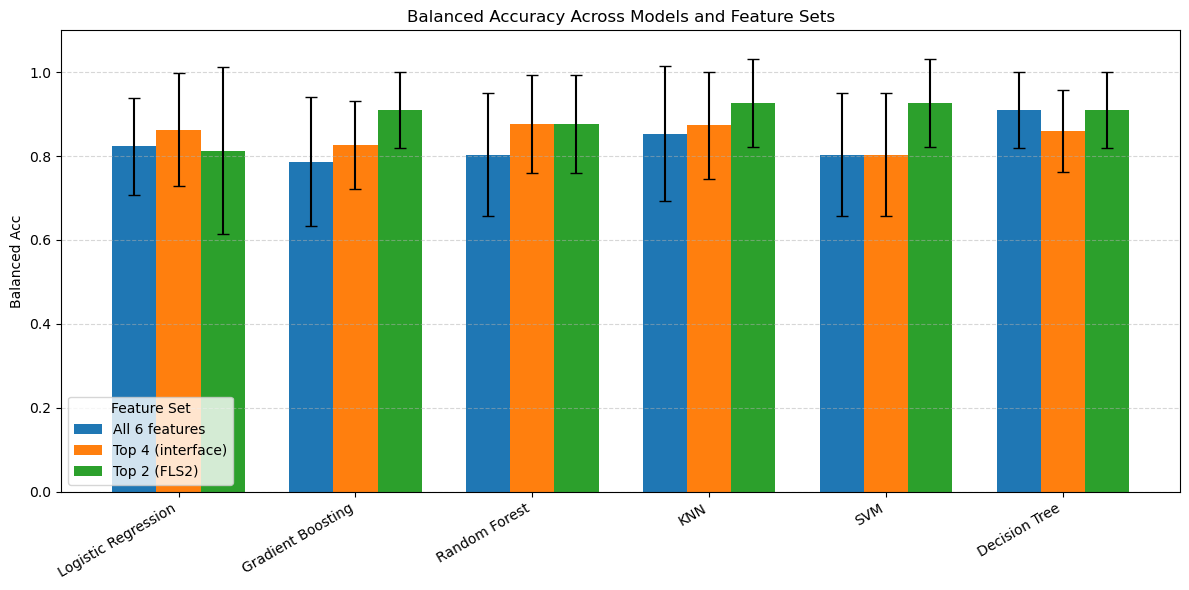

In [34]:
# Plot Balanced Accuracy
plot_metric(
    results_df,
    metric="Balanced Acc",
    metric_std="Balanced Acc std",
    title="Balanced Accuracy Across Models and Feature Sets"
)

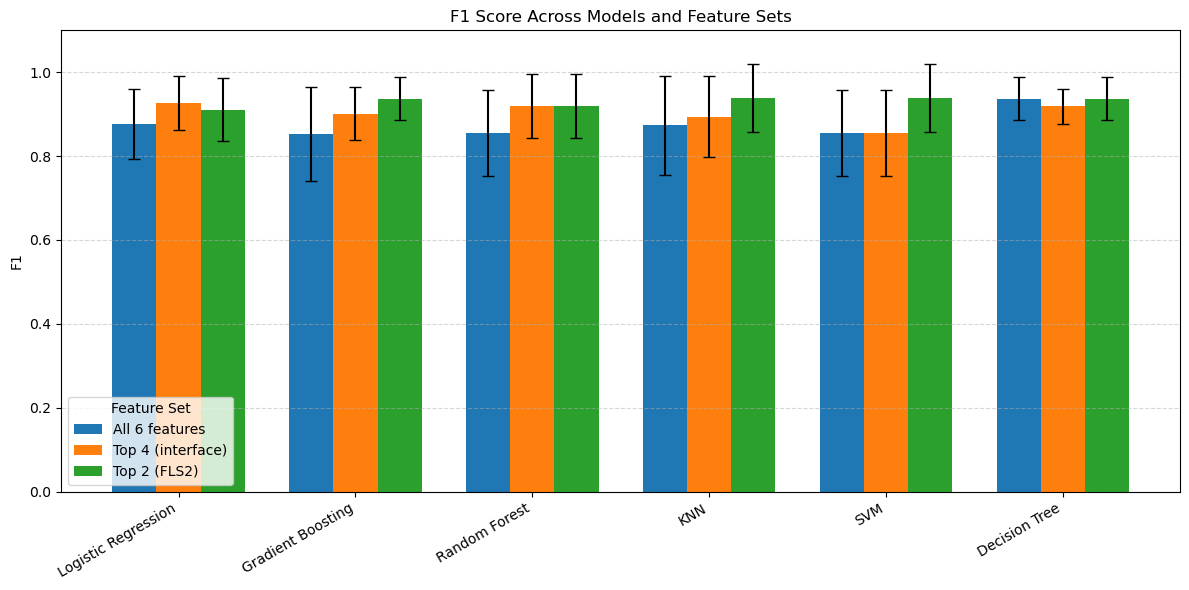

In [35]:
# Plot F1 Score

plot_metric(
    results_df,
    metric="F1",
    metric_std="F1 std",
    title="F1 Score Across Models and Feature Sets"
)